# 05. Temporal Validation
무작위 stratified split이 시간 drift를 가릴 수 있으므로 timestamp 기준 앞 80%를 Train, 뒤 20%를 Test로 분리합니다. threshold는 Temporal Train 내부의 마지막 20% validation에서만 결정합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
REPORT_DIR = PROJECT_ROOT / 'reports'

from src.secom_analysis import load_secom, data_quality_reports
from src.modeling import (
    build_baseline_models,
    classification_metrics,
    select_recall_constrained_threshold,
    threshold_table,
)
from src.temporal_validation import chronological_holdout, temporal_feature_drift

## 1. Time distribution and Fail-rate drift
전체 기간을 시간순 5개 구간으로 나눠 Fail 비율 변화를 확인합니다.

,time_quintile,samples,fail_count,fail_rate,period_start,period_end
0,0,314,44,0.140127,2008-07-19 11:55:00,2008-08-19 18:30:00
1,1,313,21,0.067093,2008-08-19 18:30:00,2008-09-01 06:52:00
2,2,313,11,0.035144,2008-09-01 08:18:00,2008-09-20 05:34:00
3,3,313,11,0.035144,2008-09-20 06:08:00,2008-10-02 19:25:00
4,4,314,17,0.054140,2008-10-02 20:54:00,2008-10-17 06:07:00


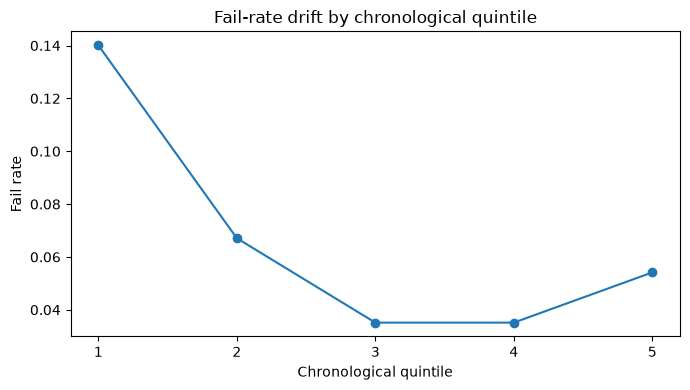

In [2]:
X, labels = load_secom(PROJECT_ROOT / 'data/raw')
_, _, _, _, kept_features = data_quality_reports(X, labels['is_fail'])
ordered = labels.sort_values('timestamp').copy()
ordered['time_quintile'] = pd.qcut(range(len(ordered)), 5, labels=False)
time_distribution = ordered.groupby('time_quintile').agg(
    samples=('is_fail', 'size'),
    fail_count=('is_fail', 'sum'),
    fail_rate=('is_fail', 'mean'),
    period_start=('timestamp', 'min'),
    period_end=('timestamp', 'max'),
).reset_index()
time_distribution.to_csv(REPORT_DIR / 'temporal_fail_distribution.csv', index=False)
display(time_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time_distribution['time_quintile'] + 1, time_distribution['fail_rate'], marker='o')
ax.set(title='Fail-rate drift by chronological quintile', xlabel='Chronological quintile', ylabel='Fail rate', xticks=range(1, 6))
fig.tight_layout()
fig.savefig(REPORT_DIR / 'temporal_fail_rate_drift.png', dpi=160)
plt.show()

## 2. Chronological Train/Validation/Test
앞 80%를 Temporal Train, 뒤 20%를 최종 Temporal Test로 둡니다. Temporal Train을 다시 앞 80% subtrain과 뒤 20% validation으로 나눠 threshold를 정합니다.

In [3]:
X_model = X[kept_features]
y = labels['is_fail']
timestamps = labels['timestamp']
X_train, X_test, y_train, y_test, ts_train, ts_test = chronological_holdout(
    X_model, y, timestamps, test_size=0.20
)
X_subtrain, X_validation, y_subtrain, y_validation, _, _ = chronological_holdout(
    X_train, y_train, ts_train, test_size=0.20
)
print('Subtrain:', len(X_subtrain), 'Fail:', int(y_subtrain.sum()))
print('Validation:', len(X_validation), 'Fail:', int(y_validation.sum()))
print('Temporal Test:', len(X_test), 'Fail:', int(y_test.sum()))
print('Test period:', ts_test.min(), 'to', ts_test.max())

Subtrain: 1002 Fail: 76
Validation: 251 Fail: 11
Temporal Test: 314 Fail: 17
Test period: 2008-10-02 20:54:00 to 2008-10-17 06:07:00


## 3. Temporal threshold selection
Random Forest를 subtrain에 적합하고 validation에서 Fail Recall 80% 이상을 만족하면서 Precision이 가장 높은 threshold를 선택합니다. 비교를 위해 Step 3의 stratified threshold 0.06도 함께 평가합니다.

In [4]:
validation_model = build_baseline_models()['random_forest_balanced']
validation_model.fit(X_subtrain, y_subtrain)
validation_probability = validation_model.predict_proba(X_validation)[:, 1]
temporal_thresholds = threshold_table(y_validation, validation_probability)
temporal_threshold = select_recall_constrained_threshold(temporal_thresholds, minimum_recall=0.80)
temporal_thresholds['selected'] = temporal_thresholds['threshold'].eq(temporal_threshold)
temporal_thresholds.to_csv(REPORT_DIR / 'temporal_threshold_comparison.csv', index=False)
print('Temporal threshold:', temporal_threshold)
display(temporal_thresholds.loc[temporal_thresholds['selected']])

Temporal threshold: 0.04


,threshold,fail_recall,precision,f1,pr_auc,balanced_accuracy,true_negative,false_positive,false_negative,true_positive,selected
3,0.04,1.0,0.053659,0.101852,0.059307,0.595833,46,194,0,11,True


## 4. Final future-period Test
동일 Random Forest를 전체 Temporal Train에 다시 적합한 뒤 미래 기간 Test를 평가합니다.

,evaluation,model,threshold,fail_recall,precision,f1,pr_auc,balanced_accuracy,true_negative,false_positive,false_negative,true_positive
0,temporal_tuned_threshold,random_forest_balanced,0.04,0.941176,0.057762,0.108844,0.097097,0.531194,36,261,1,16
1,step3_fixed_threshold,random_forest_balanced,0.06,0.647059,0.063953,0.116402,0.097097,0.552486,136,161,6,11


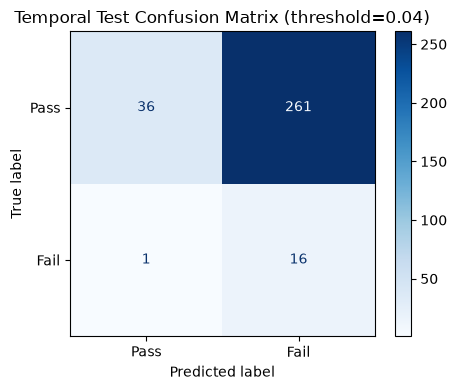

In [5]:
temporal_model = build_baseline_models()['random_forest_balanced']
temporal_model.fit(X_train, y_train)
test_probability = temporal_model.predict_proba(X_test)[:, 1]
temporal_metrics = pd.DataFrame([
    {'evaluation': 'temporal_tuned_threshold', **classification_metrics(y_test, test_probability, temporal_threshold, model='random_forest_balanced')},
    {'evaluation': 'step3_fixed_threshold', **classification_metrics(y_test, test_probability, 0.06, model='random_forest_balanced')},
])
temporal_metrics.to_csv(REPORT_DIR / 'temporal_validation_metrics.csv', index=False)
display(temporal_metrics)

prediction = (test_probability >= temporal_threshold).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, prediction, display_labels=['Pass', 'Fail'], cmap='Blues', ax=ax)
ax.set_title(f'Temporal Test Confusion Matrix (threshold={temporal_threshold:.2f})')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'temporal_confusion_matrix.png', dpi=160)
plt.show()

## 5. Monitoring-feature drift
Step 4 모니터링 후보의 Train/Test median과 결측률 변화를 계산합니다. robust sigma 단위 median 이동이 크면 threshold 성능 변화의 원인 후보로 추가 점검합니다.

In [6]:
monitoring_features = pd.read_csv(REPORT_DIR / 'monitoring_candidates.csv')['feature'].tolist()
drift = temporal_feature_drift(X_train, X_test, monitoring_features)
drift.to_csv(REPORT_DIR / 'temporal_feature_drift.csv', index=False)
display(drift)

,feature,train_median,test_median,train_mad,median_shift_robust_sigma,train_missing_rate,test_missing_rate,missing_rate_change,abs_median_shift_robust_sigma
0,feature_452,5.15860,5.76685,0.54305,0.755472,0.000798,0.000000,-0.000798,0.755472
1,feature_125,1.08700,1.22900,0.14570,0.657362,0.004789,0.009554,0.004766,0.657362
2,feature_130,0.76810,0.71540,0.05490,-0.647462,0.004789,0.009554,0.004766,0.647462
3,feature_59,1.37545,-0.78820,3.08725,-0.472706,0.005587,0.000000,-0.005587,0.472706
4,feature_103,-0.00980,-0.01110,0.00200,-0.438419,0.001596,0.000000,-0.001596,0.438419
5,feature_510,49.02510,41.04955,14.65010,-0.367194,0.001596,0.000000,-0.001596,0.367194
6,feature_129,-0.14190,-0.33110,0.42570,-0.299774,0.004789,0.009554,0.004766,0.299774
7,feature_205,7.89000,7.29500,1.94000,-0.206867,0.004789,0.000000,-0.004789,0.206867
8,feature_477,5.36340,4.96715,1.31060,-0.203927,0.004789,0.000000,-0.004789,0.203927
9,feature_33,8.76960,8.77860,0.21000,0.028907,0.000798,0.000000,-0.000798,0.028907


## Interpretation limits
시간순 Test는 실제 미래 배치와 더 유사하지만 단일 3개월 데이터의 한 번의 분할입니다. Temporal validation의 Fail 수도 적어 선택 threshold가 불안정할 수 있습니다. 결과는 무작위 split 성능과 함께 제시하고, 실제 적용 전 rolling backtest와 기간별 재학습 기준을 검증해야 합니다.